# All units are in MW

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

In [2]:

import glob
# Get a list of all CSV files in the 'data' directory
csv_files = glob.glob('demand data/*.csv')
# Create an empty list to store the dataframes
dfs = []
# Loop through each CSV file, read it into a dataframe, and append it to the list
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)
# Concatenate all dataframes in the list into a single dataframe
merged_df = pd.concat(dfs, ignore_index=True)
# Save the merged dataframe to a new CSV file
merged_df.to_csv('merged_demand_data.csv', index=False)


In [3]:
merged_df[merged_df['SETTLEMENT_DATE'].isna()]

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,SCOTTISH_TRANSFER


In [4]:
#merged_df1 = merged_df.drop(columns=['NON_BM_STOR',	'SCOTTISH_TRANSFER', 'IFA_FLOW','IFA2_FLOW', 'BRITNED_FLOW',	'MOYLE_FLOW', 'EAST_WEST_FLOW', 'NEMO_FLOW', 'NSL_FLOW', 'ELECLINK_FLOW', 'VIKING_FLOW', 'GREENLINK_FLOW'])
#print(merged_df1.head())

In [6]:
merged_df['SETTLEMENT_DATE'] = pd.to_datetime(merged_df['SETTLEMENT_DATE'], format= 'mixed', errors='coerce')
#merged_df['Year'] = merged_df['SETTLEMENT_DATE'].dt.year
#print(f"dtype of column: {merged_df.dtypes}")

In [7]:
#merged_df1['SETTLEMENT_DATE'] = pd.to_datetime(merged_df1['SETTLEMENT_DATE'], format='%Y-%m-%d')
#merged_df1['SETTLEMENT_DATE'] = merged_df1['SETTLEMENT_DATE'].dt.strftime('%Y-%m-%d')

In [8]:
print(merged_df.head())

  SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
0      2010-01-01                  1  36453  37593                 32391   
1      2010-01-01                  2  36680  37739                 32590   
2      2010-01-01                  3  36343  37467                 32291   
3      2010-01-01                  4  35362  36489                 31366   
4      2010-01-01                  5  34366  35563                 30522   

   EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
0                       906                    1786   
1                       926                    1786   
2                       926                    1786   
3                       952                    1786   
4                       952                    1786   

   EMBEDDED_SOLAR_GENERATION  EMBEDDED_SOLAR_CAPACITY  NON_BM_STOR  ...  \
0                          0                        0            0  ...   
1                          0                        0         

In [9]:
print(merged_df.tail())

       SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
281899      2026-01-29                 44  33935  35418                 31482   
281900      2026-01-29                 45  31873  33079                 29588   
281901      2026-01-29                 46  30217  31208                 28086   
281902      2026-01-29                 47  28193  29157                 26243   
281903      2026-01-29                 48  26709  27676                 24927   

        EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
281899                      3303                    6606   
281900                      3274                    6606   
281901                      3244                    6606   
281902                      3289                    6606   
281903                      3334                    6606   

        EMBEDDED_SOLAR_GENERATION  EMBEDDED_SOLAR_CAPACITY  NON_BM_STOR  ...  \
281899                          0                    21504            0 

In [10]:
merged_df['FULL_TIMESTAMP'] = merged_df['SETTLEMENT_DATE'] + (merged_df['SETTLEMENT_PERIOD'] - 1) * pd.Timedelta(minutes=30)
print(merged_df.head())

  SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
0      2010-01-01                  1  36453  37593                 32391   
1      2010-01-01                  2  36680  37739                 32590   
2      2010-01-01                  3  36343  37467                 32291   
3      2010-01-01                  4  35362  36489                 31366   
4      2010-01-01                  5  34366  35563                 30522   

   EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
0                       906                    1786   
1                       926                    1786   
2                       926                    1786   
3                       952                    1786   
4                       952                    1786   

   EMBEDDED_SOLAR_GENERATION  EMBEDDED_SOLAR_CAPACITY  NON_BM_STOR  ...  \
0                          0                        0            0  ...   
1                          0                        0         

In [11]:
merged_df['HALF_HOURLY'] = merged_df['FULL_TIMESTAMP'].dt.time
merged_df['DAY_OF_WEEK'] = merged_df['FULL_TIMESTAMP'].dt.dayofweek
merged_df['MONTH'] = merged_df['FULL_TIMESTAMP'].dt.month
print(merged_df.head())

  SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
0      2010-01-01                  1  36453  37593                 32391   
1      2010-01-01                  2  36680  37739                 32590   
2      2010-01-01                  3  36343  37467                 32291   
3      2010-01-01                  4  35362  36489                 31366   
4      2010-01-01                  5  34366  35563                 30522   

   EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
0                       906                    1786   
1                       926                    1786   
2                       926                    1786   
3                       952                    1786   
4                       952                    1786   

   EMBEDDED_SOLAR_GENERATION  EMBEDDED_SOLAR_CAPACITY  NON_BM_STOR  ...  \
0                          0                        0            0  ...   
1                          0                        0         

In [ ]:
# regional spllit from ND
#region_shares = {
#    "London": 0.14,
#    "South_East": 0.15,
#    "South_West": 0.11,
#    "Midlands": 0.19,
#    "North_West": 0.13,
#    "North_East": 0.125,
#    "South_Scotland": 0.125,
#    "North_Scotland": 0.03
#}
#for region, share in region_shares.items():
#    merged_df1[region] = merged_df1['ND'] * share

In [12]:
#merged_df["regional_sum"] = merged_df[["London", "South_East", "South_West", "Midlands", "North_West", "North_East", "South_Scotland", "North_Scotland"]].sum(axis=1)
print(merged_df.head())

  SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
0      2010-01-01                  1  36453  37593                 32391   
1      2010-01-01                  2  36680  37739                 32590   
2      2010-01-01                  3  36343  37467                 32291   
3      2010-01-01                  4  35362  36489                 31366   
4      2010-01-01                  5  34366  35563                 30522   

   EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
0                       906                    1786   
1                       926                    1786   
2                       926                    1786   
3                       952                    1786   
4                       952                    1786   

   EMBEDDED_SOLAR_GENERATION  EMBEDDED_SOLAR_CAPACITY  NON_BM_STOR  ...  \
0                          0                        0            0  ...   
1                          0                        0         

merged_df[["ND", "regional_sum"]].head()

In [13]:
# Quick analysis example
weekly_avg = merged_df.groupby('DAY_OF_WEEK')['ENGLAND_WALES_DEMAND'].mean()
print(weekly_avg)

DAY_OF_WEEK
0    28495.451866
1    29125.661278
2    29170.852180
3    29090.147919
4    28507.307112
5    25653.430969
6    25031.034220
Name: ENGLAND_WALES_DEMAND, dtype: float64


In [14]:
# This saves the file to your current working directory
#merged_df1.to_csv('merged_data.csv', index=False)

In [15]:
# -------------------------------
# 2. Feature Engineering
# -------------------------------

# Combine renewables
merged_df["renewables"] = (
    merged_df["EMBEDDED_WIND_GENERATION"] +
    merged_df["EMBEDDED_SOLAR_GENERATION"]
)

# Combine ALL interconnector flows
interconnector_cols = [
    "IFA_FLOW", "IFA2_FLOW", "BRITNED_FLOW",
    "MOYLE_FLOW", "EAST_WEST_FLOW", "NEMO_FLOW",
    "NSL_FLOW", "ELECLINK_FLOW", "VIKING_FLOW", "GREENLINK_FLOW"
]

merged_df["interconnector"] = merged_df[interconnector_cols].sum(axis=1)

In [16]:

# -------------------------------
# 3. Normalisation


def min_max_normalise(series):
    return (series - series.min()) / (series.max() - series.min())

merged_df["demand_norm"] = min_max_normalise(merged_df["ND"])
merged_df["renewables_norm"] = min_max_normalise(merged_df["renewables"])
merged_df["interconnector_norm"] = min_max_normalise(merged_df["interconnector"])

In [ ]:
# 4. Parameters


BASE_PRICE = 20
ALPHA = 40
BETA = 15
GAMMA = 10
DELTA = 150

In [20]:
# 5. Price Model

def calculate_price(row):
    demand = row["demand_norm"]
    renewables = row["renewables_norm"]
    interconnector = row["interconnector_norm"]

    price = (
        BASE_PRICE
        + ALPHA * demand
        - BETA * renewables
        - GAMMA * interconnector
    )

    # Stress (price spikes)
    stress = demand - renewables
    if stress > 0:
        price += DELTA * (stress ** 2)

    return max(price, 0)

merged_df["simulated_price"] = merged_df.apply(calculate_price, axis=1)

In [21]:

# 6. Add Time Feature (from settlement period)
# -------------------------------

# Each settlement period = 30 mins → convert to hour
merged_df["hour"] = (merged_df["SETTLEMENT_PERIOD"] - 1) / 2

def add_peak_premium(row):
    if 7 <= row["hour"] <= 10 or 16 <= row["hour"] <= 20:
        return row["simulated_price"] + 10
    return row["simulated_price"]

merged_df["simulated_price"] = merged_df.apply(add_peak_premium, axis=1)

In [22]:
merged_df.to_csv("simulated_prices.csv", index=False)

print(merged_df[["SETTLEMENT_DATE", "SETTLEMENT_PERIOD", "simulated_price"]].head())

  SETTLEMENT_DATE  SETTLEMENT_PERIOD  simulated_price
0      2010-01-01                  1        70.105377
1      2010-01-01                  2        70.446448
2      2010-01-01                  3        69.755729
3      2010-01-01                  4        67.655356
4      2010-01-01                  5        65.710970


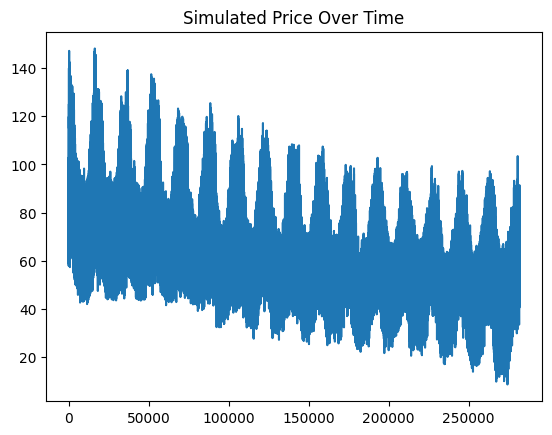

In [23]:


plt.plot(merged_df["simulated_price"])
plt.title("Simulated Price Over Time")
plt.show()

In [24]:
merged_df[["renewables", "simulated_price"]].corr()

,renewables,simulated_price
renewables,1.000000,-0.504213
simulated_price,-0.504213,1.000000


In [25]:
print(merged_df["simulated_price"].max())

148.15966949471022


In [26]:
merged_df[["ND", "simulated_price"]].corr()

,ND,simulated_price
ND,1.000000,0.886349
simulated_price,0.886349,1.000000


In [27]:
merged_df.head

<bound method NDFrame.head of        SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
0           2010-01-01                  1  36453  37593                 32391   
1           2010-01-01                  2  36680  37739                 32590   
2           2010-01-01                  3  36343  37467                 32291   
3           2010-01-01                  4  35362  36489                 31366   
4           2010-01-01                  5  34366  35563                 30522   
...                ...                ...    ...    ...                   ...   
281899      2026-01-29                 44  33935  35418                 31482   
281900      2026-01-29                 45  31873  33079                 29588   
281901      2026-01-29                 46  30217  31208                 28086   
281902      2026-01-29                 47  28193  29157                 26243   
281903      2026-01-29                 48  26709  27676                 24927  

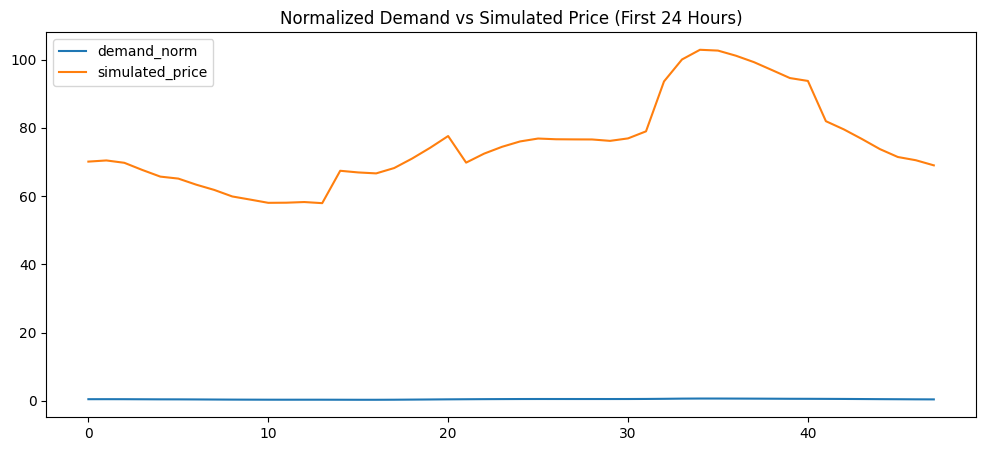

In [28]:
import matplotlib.pyplot as plt

# Plotting the first 48 half-hour settlement periods (1 day)
merged_df.iloc[:48].plot(y=['demand_norm', 'simulated_price'], figsize=(12, 5))
plt.title("Normalized Demand vs Simulated Price (First 24 Hours)")
plt.show()